In [31]:
import yfinance as yf

In [32]:
ticker = yf.Ticker('AAPL')

In [33]:
ticker.options

('2026-07-20',
 '2026-07-22',
 '2026-07-24',
 '2026-07-27',
 '2026-07-29',
 '2026-07-31',
 '2026-08-07',
 '2026-08-14',
 '2026-08-21',
 '2026-08-28',
 '2026-09-18',
 '2026-10-16',
 '2026-11-20',
 '2026-12-18',
 '2027-01-15',
 '2027-02-19',
 '2027-03-19',
 '2027-06-17',
 '2027-09-17',
 '2027-12-17',
 '2028-01-21',
 '2028-03-17',
 '2028-12-15')

In [34]:
type(ticker.options)

tuple

In [35]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations
from optionanalytics.models.market import MarketData
from optionanalytics.volatility.smile import build_smile

underlying = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,      # Placeholder
)

In [36]:

expiries = ['2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20']
# expiries = ticker.options

smile_list = []

for expiry in expiries:
    chain = fetch_option_chain(underlying, expiry)
    
    clean_chain = clean_option_chain(chain)
    
    clean_chain = filter_price_bound_violations(
        clean_chain,
        market_data,
        valuation_date,
    )
    
    smile = build_smile(
        clean_chain,
        market_data,
        valuation_date,
    )
    smile_list.append(smile)
    

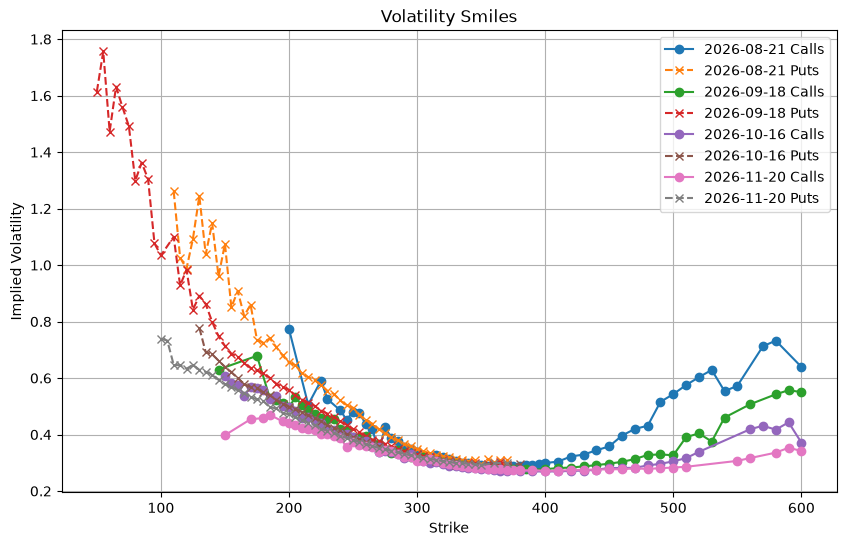

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for smile in smile_list:
    calls = [p for p in smile.points if p.option_type.name == "CALL"]
    puts = [p for p in smile.points if p.option_type.name == "PUT"]

    calls = sorted(calls, key=lambda p: p.strike)
    puts = sorted(puts, key=lambda p: p.strike)

    plt.plot(
        [p.strike for p in calls],
        [p.implied_volatility for p in calls],
        marker="o",
        label=f"{smile.expiry} Calls",
    )

    plt.plot(
        [p.strike for p in puts],
        [p.implied_volatility for p in puts],
        marker="x",
        linestyle="--",
        label=f"{smile.expiry} Puts",
    )

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smiles")
plt.grid(True)
plt.legend()
plt.show()

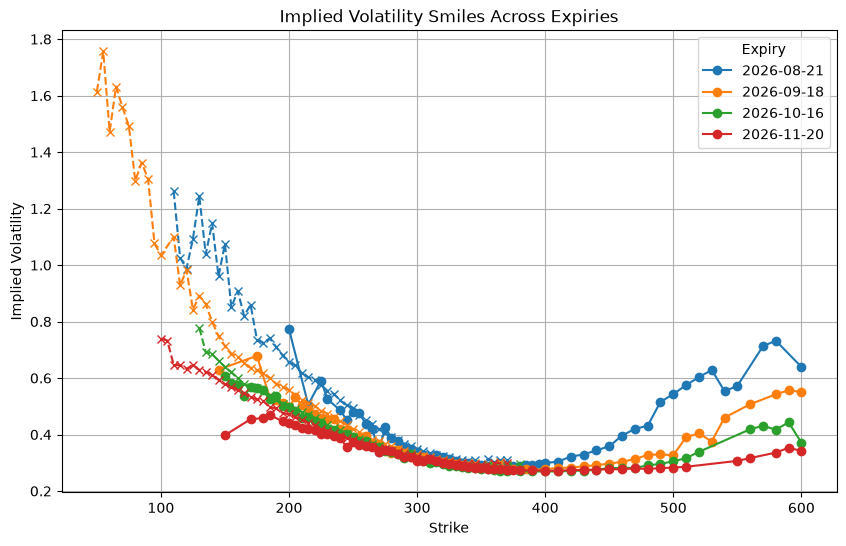

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

for smile in smile_list:
    calls = sorted(
        [p for p in smile.points if p.option_type.name == "CALL"],
        key=lambda p: p.strike,
    )
    puts = sorted(
        [p for p in smile.points if p.option_type.name == "PUT"],
        key=lambda p: p.strike,
    )

    line = ax.plot(
        [p.strike for p in calls],
        [p.implied_volatility for p in calls],
        marker="o",
        label=str(smile.expiry),
    )[0]

    ax.plot(
        [p.strike for p in puts],
        [p.implied_volatility for p in puts],
        "--",
        marker="x",
        color=line.get_color(),
    )

ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.set_title("Implied Volatility Smiles Across Expiries")
ax.grid(True)
ax.legend(title="Expiry")

plt.show()

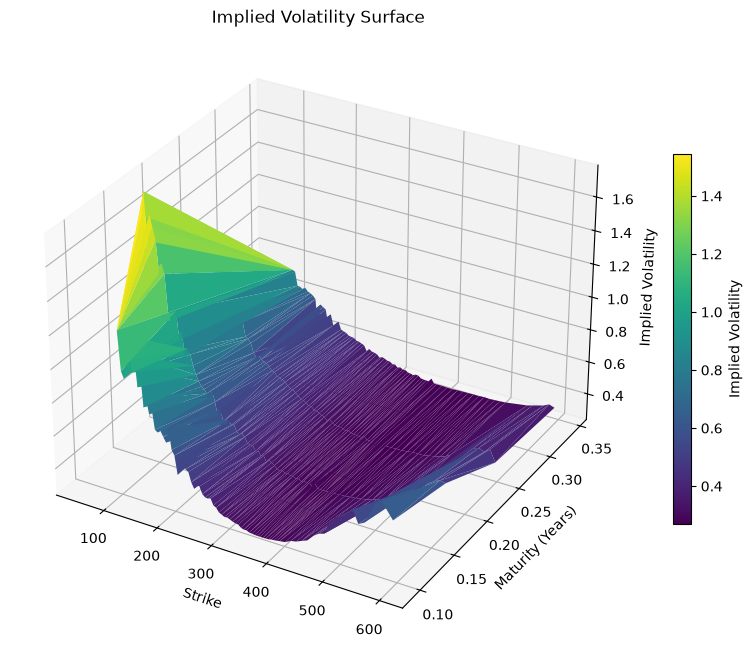

In [40]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import datetime

strikes = []
maturities = []
vols = []

for smile in smile_list:
    maturity = (
        smile.expiry - valuation_date
    ).days / 365.0

    for point in smile.points:
        strikes.append(point.strike)
        maturities.append(maturity)
        vols.append(point.implied_volatility)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_trisurf(
    strikes,
    maturities,
    vols,
    cmap="viridis",
    edgecolor="none",
)

ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (Years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Implied Volatility Surface")

fig.colorbar(surf, shrink=0.6, label="Implied Volatility")

plt.show()

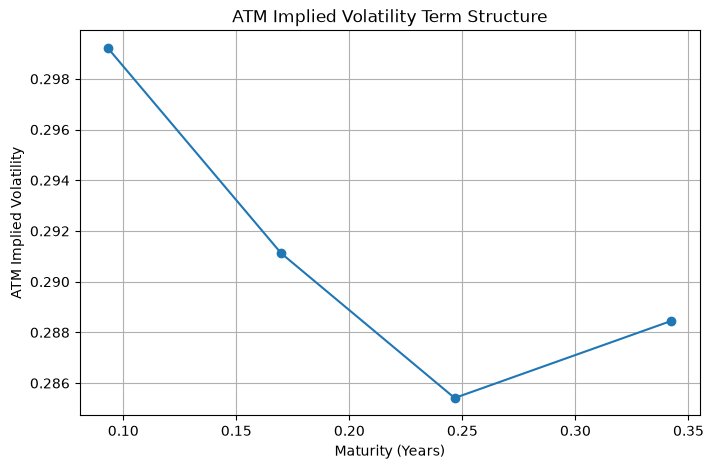

In [41]:
maturities = []
atm_ivs = []

for smile in smile_list:
    maturity = (smile.expiry - valuation_date).days / 365.0

    # Point whose strike is closest to spot
    atm_point = min(
        smile.points,
        key=lambda p: abs(p.strike - market_data.spot),
    )

    maturities.append(maturity)
    atm_ivs.append(atm_point.implied_volatility)

plt.figure(figsize=(8, 5))

plt.plot(
    maturities,
    atm_ivs,
    marker="o",
)

plt.xlabel("Maturity (Years)")
plt.ylabel("ATM Implied Volatility")
plt.title("ATM Implied Volatility Term Structure")
plt.grid(True)

plt.show()